<a href="https://colab.research.google.com/github/vrodriguezrey/Practica4_redes_imagenes/blob/main/PARAMETROS_KFOLD_Practica_clasif_imagenes_vehiculos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models
from tensorflow.keras import optimizers

from tensorflow.keras.applications import VGG16

from google.colab import drive


from skimage import io, transform, color
import os
from pathlib import Path

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#Lectura de imágenes de Drive
dataset_path='/content/drive/MyDrive/Colab Notebooks/Dataset/'
class_names = ["Bus", "Car", "motorcycle", "Truck"]
subcarpetas= ["/content/drive/MyDrive/Colab Notebooks/Dataset/Bus", "/content/drive/MyDrive/Colab Notebooks/Dataset/Car",
              "/content/drive/MyDrive/Colab Notebooks/Dataset/motorcycle", "/content/drive/MyDrive/Colab Notebooks/Dataset/Truck"]

n_classes=len(class_names)
img_size=224
images=[]
target=[]
trg=0

#Carga del dataset de drive
for carpeta in subcarpetas:#recorre cada carpeta

  for archivo in os.listdir(carpeta):#obtiene todos los archivos dentro de una carpeta
    path_image=os.path.join(carpeta,archivo)
    img=io.imread(path_image)

    # Si la imagen tiene 4 canales (RGBA), convertirla a RGB
    if img.shape[2] == 4:  # 4 canales (RGBA)
      img = color.rgba2rgb(img)  # Convertir a RGB (3 canales)

    img = transform.resize(img, (img_size, img_size), anti_aliasing=True)

    images.append(img)
    target.append(trg)

  trg=trg+1

images_array=np.array(images)
target_array=np.array(target)

num_images, alto, ancho, canales = images_array.shape
print("Número de imágenes: ", num_images)
print(f"Resolución de las imágenes: {alto}x{ancho}x{canales}")
print("Número de clases: ",n_classes)
print("Clases: ", class_names)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Número de imágenes:  364
Resolución de las imágenes: 224x224x3
Número de clases:  4
Clases:  ['Bus', 'Car', 'motorcycle', 'Truck']


Clase: Bus
Target: 0


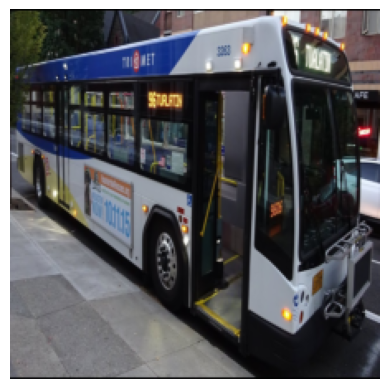

In [6]:
#Visualización de la primera imagen
print(f"Clase: {class_names[target[1]]}")
print(f"Target: {target_array[1]}")
plt.imshow(images_array[1], cmap='gray')
plt.axis("off")
plt.show()

In [7]:
def create_model(activation_function, dropout_rate, pretrained_model, input_img_shape, img_size, num_classes, optimizer, loss, metrics, capas, n_capa1, n_capa2, n_capa3):
    # Crear el modelo
    model = models.Sequential()

    model.add(layers.InputLayer(shape=input_img_shape)) #Capa de entrada
    model.add(layers.Resizing(img_size, img_size)) #Capa de resizing

    # Data augmentation
    #model.add(layers.Rescaling(1./255)) Esta no se añade si las imágenes están ya normalizadas
    #model.add(layers.RandomFlip("horizontal_and_vertical"))
    #model.add(layers.RandomRotation(0.2))

    # Añadir la base convolucional cargada
    model.add(pretrained_model)

    # Añadir nuevas capas
    model.add(layers.Flatten())
    model.add(layers.Dense(n_capa1, activation=activation_function))
    #model.add(layers.Dropout(dropout_rate))
    if n_capa2!=0:
      model.add(layers.Dense(n_capa2, activation=activation_function))
      model.add(layers.Dropout(dropout_rate)) #Comentar para variar capas de dropout
    if n_capa3!=0:
      model.add(layers.Dense(n_capa3, activation=activation_function))
      model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    # Mostrar resumen del modelo
    model.summary()

    model.compile(
      optimizer=optimizer,
      loss=loss,
      metrics=metrics)

    return model

In [8]:
def plot_history(history, type):
      plt.figure(figsize=(15,5))
      plt.plot(history.history[type], label=type)
      plt.plot(history.history['val_'+type], label='Val '+type)
      plt.xlabel('Epoch')
      plt.ylabel('Error [MPG]')
      plt.legend()
      plt.grid(True)


In [9]:
# Fijamos al semilla para hacer determinista el entrenamiento.
SEED_VALUE = 0
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)
tf.keras.utils.set_random_seed(SEED_VALUE)
tf.config.experimental.enable_op_determinism()

In [10]:
#DIVISION DE DATOS (TRAIN TEST) -> HAY QUE USAR 5 FOLD
#Se realiza una partición simple para reservar los datos de test y que no entren en el 5 FOLD
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(images_array, target_array, random_state=4)

k_folds=5
kf_sh = KFold(n_splits=k_folds, shuffle=True, random_state=4)

In [16]:
#CONFIGURACIÓN DE LA RED

neuronas_ini=64
rango=[0.5,1,2]

#Modelo convolucional
Modelo="VGG16"
#Función de activación
#activation_function = tf.keras.activations.relu
activation_function="relu"
#Tamaño de batch
lote=64
#Tolerancia
tolerancia=0.1
#Nº máx. iteraciones
n_iter_no_change = 15
#Nº de capas de dropout, desactivar capas en la siguiente sección si se quiere probar o variar el % de neuronas a desactivar
dropout_rate=0.1
#Learning Rate
aprendizaje=0.001

#Otros
max_epochs = 200


#Función callback
earlystop_callback = callbacks.EarlyStopping(monitor='val_loss', verbose = 0, min_delta=tolerancia, restore_best_weights = True, patience=n_iter_no_change)


In [17]:
# Prueba con diferentes modelos Pre-entrenados
if Modelo=="VGG16":
  img_size=224 #hacer prueba con 150
  # Cargar el modelo VGG16 con todas las capas que tiene
  conv = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
  output_path='/content/drive/MyDrive/Colab Notebooks/OUTPUT/PRUEBAS_PARAM/'

if Modelo=="XCEPTION": #Opción 2 - Xception: se espera que sea más lento pero más preciso
  img_size=299
  conv=keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
  output_path='/content/drive/MyDrive/Colab Notebooks/OUTPUT/PRUEBAS_PARAM/'

if Modelo=="INCEPTIONV3":#Opción 3
  img_size=299
  conv=keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
  output_path='/content/drive/MyDrive/Colab Notebooks/OUTPUT/PRUEBAS_PARAM/'

# Congelar todas la capas, evitar que se entrenen estas capas
for layer in conv.layers[:]:
    layer.trainable = False

# Comprobar el atributo "trainable" de cada capa SOlo muestra info
for layer in conv.layers:
  print(layer, layer.trainable)

<InputLayer name=input_layer_6, built=True> False
<Conv2D name=block1_conv1, built=True> False
<Conv2D name=block1_conv2, built=True> False
<MaxPooling2D name=block1_pool, built=True> False
<Conv2D name=block2_conv1, built=True> False
<Conv2D name=block2_conv2, built=True> False
<MaxPooling2D name=block2_pool, built=True> False
<Conv2D name=block3_conv1, built=True> False
<Conv2D name=block3_conv2, built=True> False
<Conv2D name=block3_conv3, built=True> False
<MaxPooling2D name=block3_pool, built=True> False
<Conv2D name=block4_conv1, built=True> False
<Conv2D name=block4_conv2, built=True> False
<Conv2D name=block4_conv3, built=True> False
<MaxPooling2D name=block4_pool, built=True> False
<Conv2D name=block5_conv1, built=True> False
<Conv2D name=block5_conv2, built=True> False
<Conv2D name=block5_conv3, built=True> False
<MaxPooling2D name=block5_pool, built=True> False


k_fold 1 de 5


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_5 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,934,596 (68.42 MB)

 Trainable params: 3,219,908 (12.28 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_9 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,934,596 (68.42 MB)

 Trainable params: 3,219,908 (12.28 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Neur. capa 1: 128, Neur. capa 2: 64, LR:0.001
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step


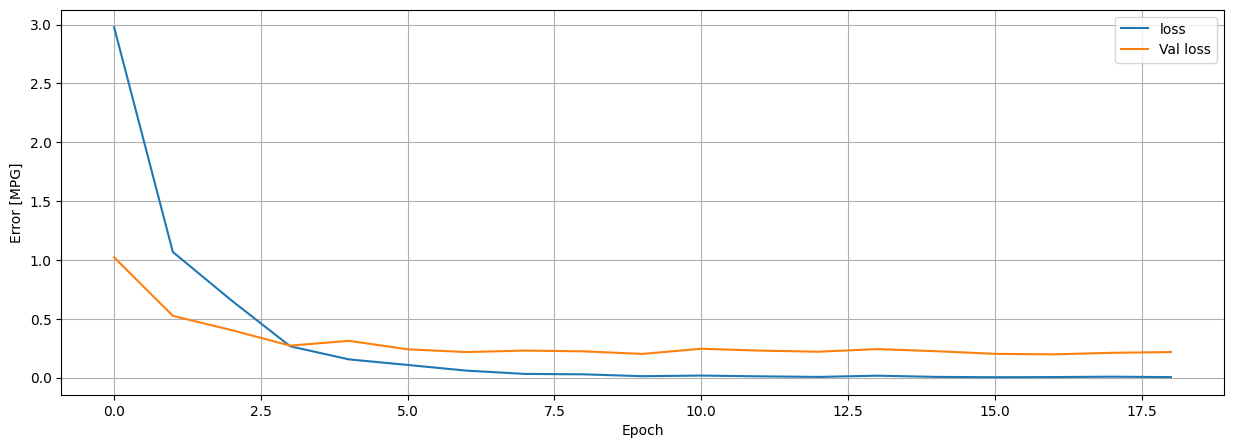

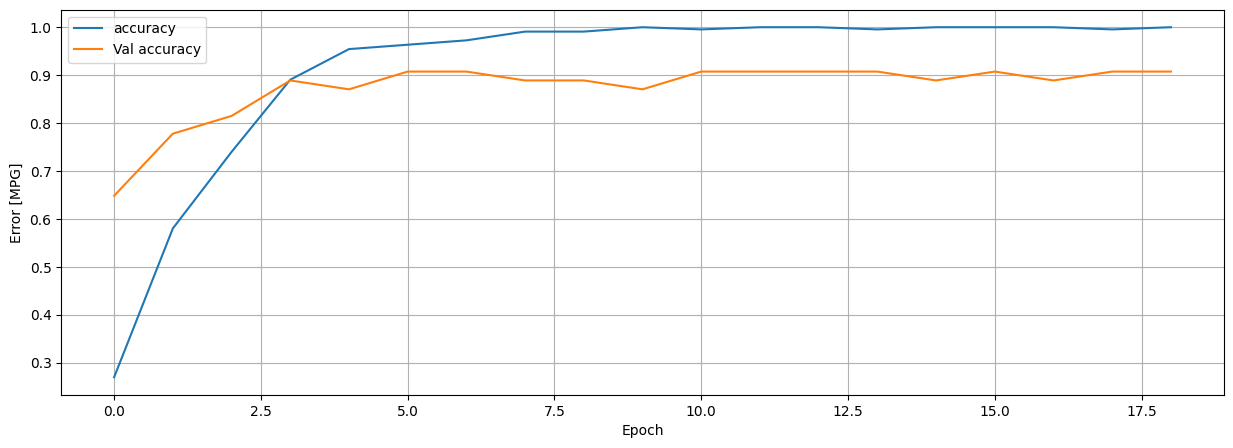

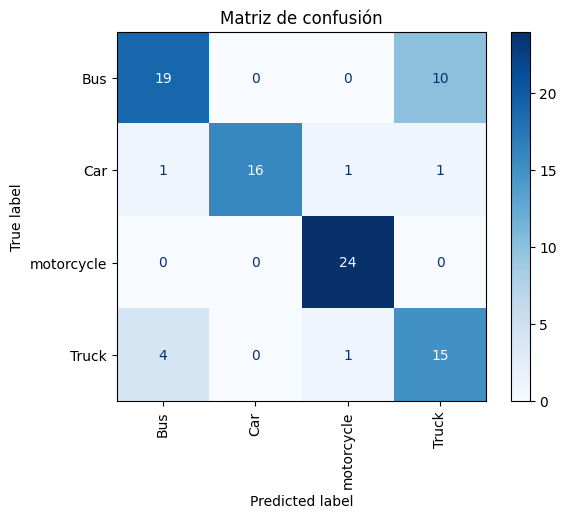

In [18]:
#CAPAS CONFIGURABLES
conf_matrix = []
clf_report = []
param_list=[]



neuronas_capa1=int(neuronas_ini*2)
#neuronas_capa2=0
neuronas_capa2=int(neuronas_ini)
neuronas_capa3=0



# Se realizan tantos entrenamientos como valor se indica en la validación cruzada
for iteracciones, (train_index, val_index) in enumerate(kf_sh.split(X_train_orig, y_train_orig)):
  # Muestra el paso de la k-fold en la que nos encontramos
    print('k_fold', iteracciones+1, 'de', k_folds)

    # Se obtienen los paquetes de datos de entrenamiento y test en base a los índices aleatorios generados en k-fold
    X_train, y_train = X_train_orig[train_index], y_train_orig[train_index]
    X_val, y_val = X_train_orig[val_index], y_train_orig[val_index]

    # Se carga el modelo en cada paso de la kfold para resetear el entrenamiento (pesos)
    model = create_model(activation_function = activation_function,
                  dropout_rate = dropout_rate,
                  pretrained_model = conv,
                  input_img_shape = (alto, ancho, canales),
                  img_size = img_size,
                  num_classes = n_classes,
                  optimizer = optimizers.Adam(learning_rate=aprendizaje),
                  loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                  metrics = ['accuracy'],
                  capas=2,
                  n_capa1=neuronas_capa1,
                  n_capa2=neuronas_capa2,
                  n_capa3=neuronas_capa3)

    param=(f"Neur. capa 1: {neuronas_capa1}, Neur. capa 2: {neuronas_capa2}, LR:{aprendizaje}")
    print(param)
    # Se realiza el entrenamiento de la red de neuronas
    history = model.fit(X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=lote,
        verbose=0,
        callbacks = [earlystop_callback])

    y_predict=model.predict(X_test_orig)
    y_predict=np.argmax(y_predict,axis=1)
    conf_matrix.append(confusion_matrix(y_test_orig, y_predict))

    # Añadimos el classification_report del estimador actual a la lista
    #clf_report.append(classification_report(y_test_orig, y_predict, output_dict=True))
    diccionario=classification_report(y_test_orig, y_predict, output_dict=True)
    clf_report.append(diccionario)
    for _ in range(7):
      param_list.append(param)

# Gráficas LOSS y ACC
plot_history(history, type='loss')
graf_loss=(f"Loss_n1_{neuronas_capa1}-n2_{neuronas_capa2}-n3_{neuronas_capa3}-LR:{aprendizaje}.png")
plt.savefig(output_path+graf_loss)
plot_history(history, type='accuracy')
graf_acc=(f"Acc_n1_{neuronas_capa1}-n2_{neuronas_capa2}-n3_{neuronas_capa3}-LR_{aprendizaje}.png")
plt.savefig(output_path+graf_acc)


#Matriz de conf media
avg_cm = np.zeros(conf_matrix[0].shape, dtype=int)
for matrix in conf_matrix:
  for ii in range(matrix.shape[0]):
      for jj in range(matrix.shape[1]):
          avg_cm[ii,jj] +=  matrix[ii,jj]
for ii in range(avg_cm.shape[0]):
  for jj in range(avg_cm.shape[1]):
      avg_cm[ii,jj] = int(round(avg_cm[ii][jj]/len(conf_matrix)))

disp = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.title("Matriz de confusión")
graf_cm=(f"CM_n1_{neuronas_capa1}-n2_{neuronas_capa2}-n3_{neuronas_capa3}-LR_{aprendizaje}.png")
plt.savefig(output_path+graf_cm)
plt.show()



In [19]:
# Convierte cada diccionario de clf_report en un DataFrame y lo guarda en una lista
df_list = [pd.DataFrame(report).T for report in clf_report]

# Combina todos los DataFrames en uno solo con múltiples niveles de índices
df = pd.concat(df_list, keys=range(len(df_list)))
#Añade al df los parámetros correspondientes a la ejecución
df["Params"]=param_list
# Calcula medias y desviaciones típicas para las métricas que quieres (recall, precision, f1-score)
medias = df.groupby(["Params", df.index.get_level_values(1)]).mean()  # Promedio por clase/métrica
desv = df.groupby(["Params", df.index.get_level_values(1)]).std()     # Desviación típica por clase/métrica

In [20]:
with pd.ExcelWriter(output_path + "\\OUTPUT_VGG16_prueba.xlsx") as writer:
    df.to_excel(writer, sheet_name="DatosenBruto")
    medias.to_excel(writer, sheet_name="Medias")
    desv.to_excel(writer,sheet_name="Desviaciones")